# Linear Regression — Closed-Form Derivation (Normal Equation)

## Goal

This notebook derives the slope ($m$) and intercept ($b$) for simple linear
regression directly — by setting up the loss function, taking partial
derivatives, and solving for the values of $m$ and $b$ that minimize error.
This is the **closed-form** solution: one direct calculation, no iteration.

The derivation is worked out from first principles, including the reasoning
behind each step — not just the formulas, but *why* each step is taken.
The result is then implemented in NumPy and validated against
`scikit-learn`'s `LinearRegression`.

## What this notebook covers

1. Defining the loss function and why it's shaped the way it is
2. Deriving $\frac{\partial E}{\partial b}$ and solving for $b$
3. Deriving $\frac{\partial E}{\partial m}$ and solving for $m$
4. Implementing the closed-form solution in NumPy
5. Validating the result against scikit-learn

## Loss Function

$$ E = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 $$

- $y_i \rightarrow$ actual value of term $i$
- $\hat{y}_i \rightarrow$ predicted value of term $i$

**Why $(y_i - \hat{y}_i)$?**
Because we need to measure the difference between the actual and the model's predicted value.

**Why squared?**
The error (difference between actual and predicted) can be positive or negative. If we just summed the raw errors, positive and negative values could cancel out, making a poor model falsely look accurate. Squaring forces every error to be positive before summing, so errors don't cancel and the total reflects the true magnitude of mistakes.

## Solving for $b$

$$ \frac{\partial E}{\partial b} = \sum_{i=1}^{n} -2(y_i - mx_i - b) = 0 $$

Dividing both sides by $-2$:

$$ \sum_{i=1}^{n} (y_i - mx_i - b) = 0 $$

Splitting the sum into three separate sums:

$$ \sum_{i=1}^{n} y_i - m\sum_{i=1}^{n} x_i - \sum_{i=1}^{n} b = 0 $$

Since $b$ is a constant, $\sum_{i=1}^{n} b = nb$:

$$ \sum_{i=1}^{n} y_i - m\sum_{i=1}^{n} x_i - nb = 0 $$

Dividing every term by $n$ (recall $\bar{y} = \frac{1}{n}\sum y_i$ and $\bar{x} = \frac{1}{n}\sum x_i$):

$$ \bar{y} - m\bar{x} - b = 0 $$

Solving for $b$:

$$ \boxed{b = \bar{y} - m\bar{x}} $$

**Interpretation:** the fitted line always passes through the point $(\bar{x}, \bar{y})$ — the mean of the data. This makes intuitive sense: if you average out all the noise, the line should pass through the "center of mass" of the dataset.

## Solving for $m$

$$ \frac{\partial E}{\partial m} = \sum_{i=1}^{n} -2(y_i - mx_i - b)(x_i) = 0 $$

Dividing by $-2$:

$$ \sum_{i=1}^{n} x_i(y_i - mx_i - b) = 0 $$

Substituting $b = \bar{y} - m\bar{x}$ from the previous step:

$$ \sum_{i=1}^{n} x_i\left(y_i - mx_i - (\bar{y} - m\bar{x})\right) = 0 $$

$$ \sum_{i=1}^{n} x_i\left((y_i - \bar{y}) - m(x_i - \bar{x})\right) = 0 $$

Distributing:

$$ \sum_{i=1}^{n} x_i(y_i - \bar{y}) - m\sum_{i=1}^{n} x_i(x_i - \bar{x}) = 0 $$

It's a standard algebraic identity that $\sum x_i(y_i - \bar y) = \sum (x_i-\bar x)(y_i-\bar y)$ and $\sum x_i(x_i - \bar x) = \sum (x_i - \bar x)^2$ (replacing $x_i$ with $(x_i - \bar x)$ inside these particular sums doesn't change their value, since the extra $\bar{x}$ or $\bar{y}$ terms introduced cancel out over the full sum). Using that:

$$ \sum_{i=1}^{n} (x_i-\bar{x})(y_i-\bar{y}) - m\sum_{i=1}^{n} (x_i - \bar{x})^2 = 0 $$

Solving for $m$:

$$ \boxed{m = \frac{\sum_{i=1}^{n} (x_i-\bar{x})(y_i-\bar{y})}{\sum_{i=1}^{n} (x_i - \bar{x})^2}} $$

**Interpretation:** the numerator is the **covariance** of $x$ and $y$ (how much they vary together), and the denominator is the **variance** of $x$ alone. So $m = \frac{\text{Cov}(x,y)}{\text{Var}(x)}$ — the slope is literally "how much $x$ and $y$ move together, scaled by how spread out $x$ is."

## Setting Up the Derivation

Our model predicts:
$$ \hat{y}_i = mx_i + b $$

Substituting into the loss function:
$$ E = \sum_{i=1}^{n} (y_i - mx_i - b)^2 $$

We want to find the values of $m$ and $b$ that minimize $E$.

**A note on terminology — two different "slopes," same symbol issue with $m$ and $b$:**

$m$ and $b$ here are the slope and intercept of the *fitted regression line* —
the same geometric meaning as in $y = mx + b$ from school math. They are
the *answers* we are solving for.

$\frac{\partial E}{\partial m}$ and $\frac{\partial E}{\partial b}$ are a
different thing entirely: they describe the slope of the **loss curve**
(how $E$ changes as $m$ or $b$ is nudged), not the slope of the regression
line itself. This is the *tool* used to find the best $m$ and $b$ — not
the line's geometry.

| Term | What it is | What changes |
|---|---|---|
| $m$, $b$ (line's slope, intercept) | The fitted line's shape — what we're solving for | Fixed once training is done |
| $\frac{\partial E}{\partial m}$, $\frac{\partial E}{\partial b}$ (loss curve's slope) | How error changes as $m$/$b$ are nudged — used to search for the minimum | Used only during the derivation/search |

**Why set the partial derivatives to zero?**
$E$ is a sum of squares, so it can never be negative — it's shaped like a
bowl with one lowest point. Walking along this bowl as $m$ (or $b$) varies,
the slope of $E$ is negative before the minimum, zero exactly at the
minimum, and positive after it. That zero-crossing is the precise
mathematical signature of the lowest point — calculus lets us solve for it
directly, instead of searching by trial and error.

(Since $E$ is a sum of squares, it grows without bound as $m$ or $b$ move to
extreme values — so the bowl has no maximum, only one minimum, confirming
the zero-derivative point we find is indeed that minimum.)

**Why differentiate with respect to $m$ and $b$ separately, rather than together?**
$E$ depends on two independent quantities — changing $m$ doesn't force $b$
to change, and vice versa. The loss surface can be flat in one direction
while still sloping in the other, so one combined derivative can't capture
both. Two unknowns require two independent equations to pin down a single
solution — so we take $\frac{\partial E}{\partial m}$ and
$\frac{\partial E}{\partial b}$ separately, and require both to equal zero
at the same time.

Code From Scratch

In [1]:
class simple_linear_regression():
    def __init__ (self):
        self.intercept_=0
        self.coef_=0
            
    def fit(self,x_train,y_train):
        x_mean=x_train.mean()
        y_mean=y_train.mean()
        numerator=((x_train-x_mean)*(y_train-y_mean)).sum()
        denominator=((x_train-x_mean)**2).sum()
        self.coef_=numerator/denominator
        self.intercept_=y_mean-(self.coef_*x_mean)
            
    def predict(self,x_test):
        y_pred=(self.coef_*x_test)+self.intercept_
        return y_pred

In [2]:
from sklearn.datasets import make_regression
X, y = make_regression(n_samples=100, n_features=1, noise=10, random_state=42)

import pandas as pd
x = pd.Series(X.flatten())   # convert to 1D Series, matches what class expects
y = pd.Series(y)


In [3]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [4]:
import pandas as pd

my_lr=simple_linear_regression()
my_lr.fit(x_train,y_train)
my_preds=my_lr.predict(x_test)
print("My_Intercept : ",my_lr.intercept_)
print("My-Coefficient : ",my_lr.coef_)

from sklearn.linear_model import LinearRegression
sk_lr=LinearRegression()
sk_lr.fit(x_train.values.reshape(-1,1),y_train)
sk_preds=sk_lr.predict(x_test.values.reshape(-1,1))
print("SK_Intercept : ",sk_lr.intercept_)
print("SK_Coef : ",sk_lr.coef_)

My_Intercept :  0.09922221422588073
My-Coefficient :  44.24418215597421
SK_Intercept :  0.09922221422588251
SK_Coef :  [44.24418216]


Validating against scikit-learn on held-out test data

In [5]:
import numpy as np
print(f"Max prediction difference: {np.max(np.abs(my_preds.values - sk_preds)):.8f}")

Max prediction difference: 0.00000000


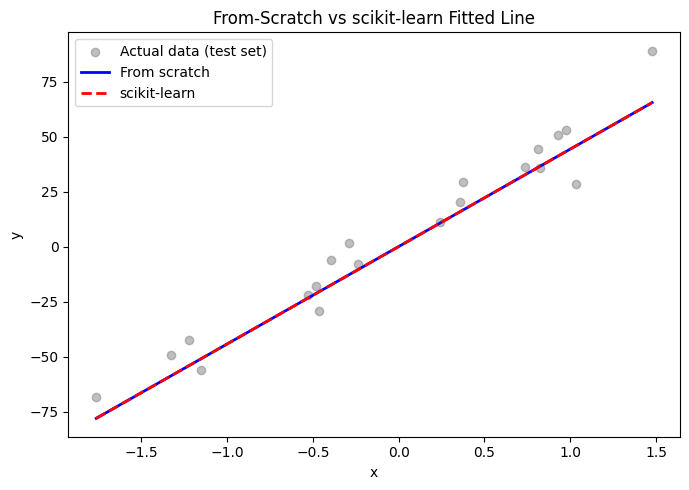

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.scatter(x_test, y_test, alpha=0.5, label="Actual data (test set)", color="gray")

x_sorted = x_test.sort_values()
plt.plot(x_sorted, my_lr.predict(x_sorted), label="From scratch", color="blue", linewidth=2)
plt.plot(x_sorted, sk_lr.predict(x_sorted.values.reshape(-1,1)), label="scikit-learn", color="red", linestyle="--", linewidth=2)

plt.xlabel("x")
plt.ylabel("y")
plt.title("From-Scratch vs scikit-learn Fitted Line")
plt.legend()
plt.tight_layout()
plt.show()

## Conclusion

This notebook derived the closed-form solution for simple linear regression
from first principles, by setting both partial derivatives of the squared
error to zero and solving directly for the slope and intercept. The
resulting formulas were implemented in NumPy/pandas with no use of
scikit-learn internals, and validated on held-out test data — the
from-scratch model's coefficients and predictions matched scikit-learn's
`LinearRegression` to within floating-point precision.

**Next:** extending this derivation to multiple independent variables,
using matrix notation instead of scalar algebra.

In [10]:
!git remote add origin https://github.com/sitharthan006/ML-Math-From-Scratch.git

Initialized empty Git repository in C:/Users/sidhu/ML-Math-From-Scratch/.git/
